## 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Using on_bad_lines='skip' to handle potential malformed rows in the CSV
df = pd.read_csv('/content/daily-minimum-temperatures-in-me.csv', on_bad_lines='skip')

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

First 5 rows of the dataset:


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column                                                         Non-Null Count  Dtype 
---  ------                                                         --------------  ----- 
 0   Date                                                           3650 non-null   object
 1   Daily minimum temperatures in Melbourne, Australia, 1981-1990  3650 non-null   object
dtypes: object(2)
memory usage: 57.2+ KB

Descriptive Statistics:


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
count,3650,3650
unique,3650,230
top,1990-12-31,10.0
freq,1,51


From the initial inspection, it appears the column names might need adjustment for clarity. The 'Date' column should be converted to datetime objects, and potentially set as the DataFrame index for time series operations. The 'Daily minimum temperatures' column will be our target variable.

In [2]:
# 1. Clean column names first (strip whitespace from all columns)
df.columns = df.columns.str.strip()

# 2. Rename the temperature column if its original name exists
original_temp_col_name = 'Daily minimum temperatures in Melbourne, Australia, 1981-1990'.strip()
if original_temp_col_name in df.columns:
    df = df.rename(columns={original_temp_col_name: 'Temperature'})

# 3. Process the 'Date' column: convert to datetime and set as index
if 'Date' in df.columns: # If 'Date' is still a regular column
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
elif df.index.name == 'Date' and not isinstance(df.index, pd.DatetimeIndex): # If 'Date' is already index but not DatetimeIndex
    df.index = pd.to_datetime(df.index) # Convert the existing index to datetime

# 4. Convert 'Temperature' column to numeric and handle NaNs
if 'Temperature' in df.columns: # Ensure 'Temperature' column exists
    df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')
    df.dropna(subset=['Temperature'], inplace=True)

# Display the updated DataFrame info and head
print("\nUpdated DataFrame after processing:")
df.info()
display(df.head())


Updated DataFrame after processing:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3647 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3647 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


,Temperature
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


## 2. Visualize the Time Series

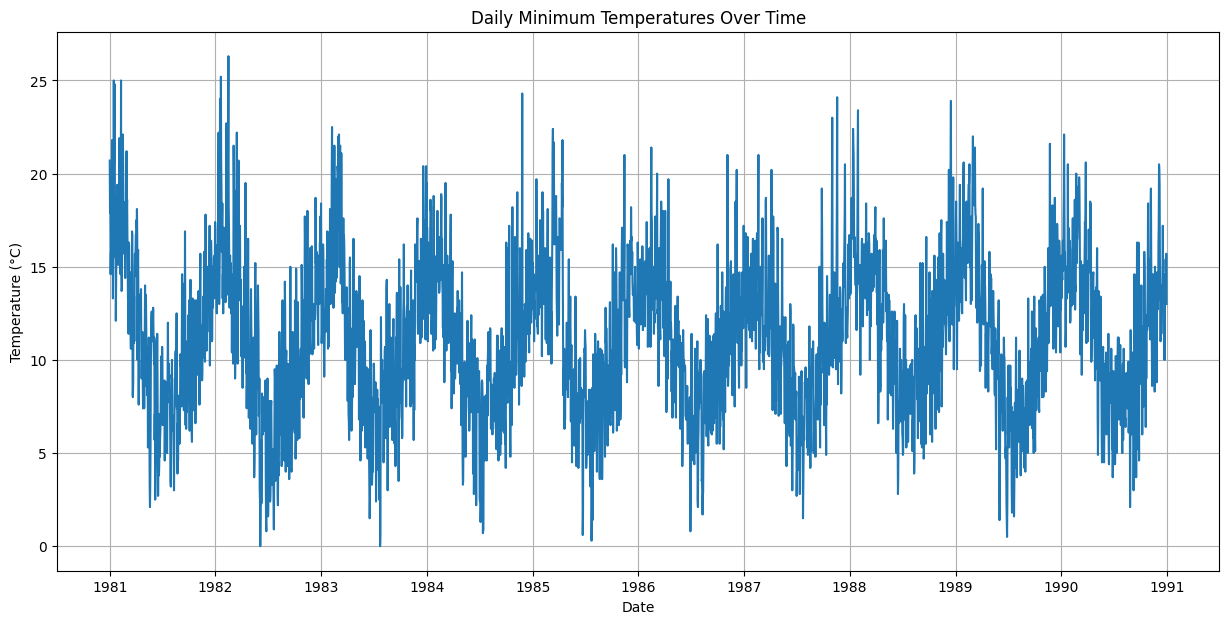

In [3]:
# Plot the time series data
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x=df.index, y='Temperature')
plt.title('Daily Minimum Temperatures Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

## 3. Stationarity Check (ADF Test)

In [4]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    if result[1] <= 0.05:
        print("Conclusion: The series is likely stationary (reject H0).")
    else:
        print("Conclusion: The series is likely non-stationary (fail to reject H0).")

print("Augmented Dickey-Fulter Test on Daily Minimum Temperatures:")
adf_test(df['Temperature'])


Augmented Dickey-Fulter Test on Daily Minimum Temperatures:
ADF Statistic: -4.444653
p-value: 0.000247
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Conclusion: The series is likely stationary (reject H0).


## 4. Seasonal Decomposition

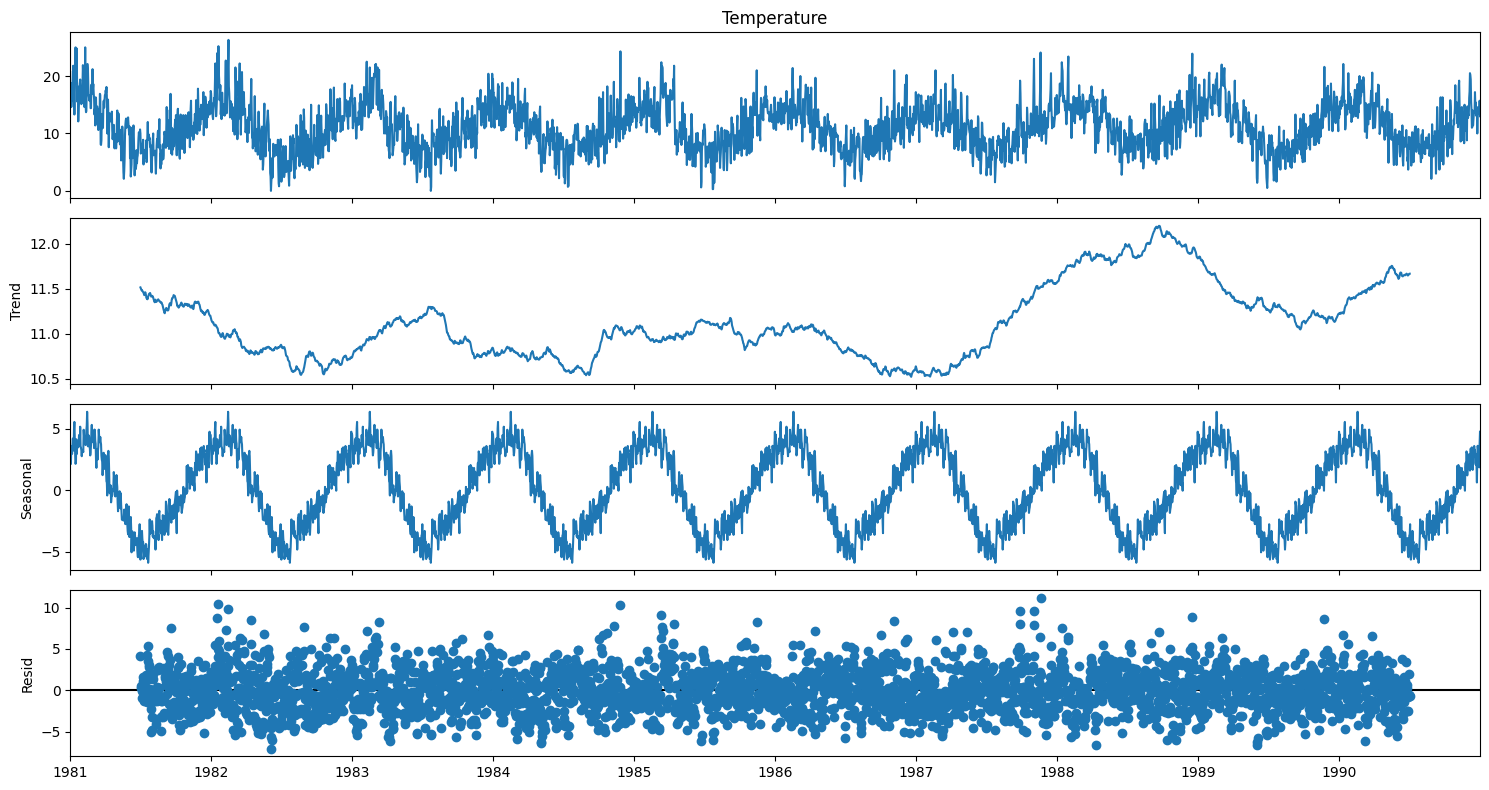


Decomposition Summary (first 5 rows of each component):
Trend:


,trend
Date,
1981-01-01,NaN
1981-01-02,NaN
1981-01-03,NaN
1981-01-04,NaN
1981-01-05,NaN


Seasonal:


,seasonal
Date,
1981-01-01,3.576722
1981-01-02,2.477362
1981-01-03,2.133313
1981-01-04,3.588016
1981-01-05,3.298488


Residual:


,resid
Date,
1981-01-01,NaN
1981-01-02,NaN
1981-01-03,NaN
1981-01-04,NaN
1981-01-05,NaN


In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['Temperature'], model='additive', period=365) # Assuming daily data and annual seasonality

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(15, 8)
plt.tight_layout()
plt.show()

# Display summary statistics of the components
print("\nDecomposition Summary (first 5 rows of each component):")
print("Trend:")
display(decomposition.trend.head())
print("Seasonal:")
display(decomposition.seasonal.head())
print("Residual:")
display(decomposition.resid.head())

## 5. Data Splitting (80-20 Sequential)

Training set has 2917 observations.
Test set has 730 observations.


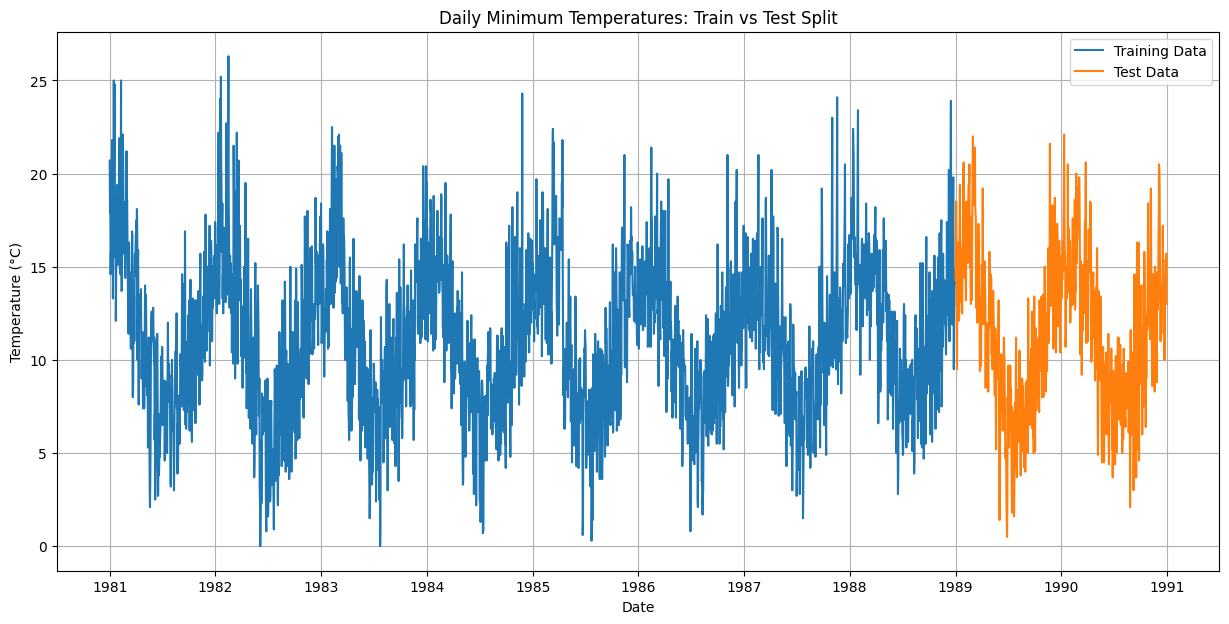

In [6]:
# Calculate the split point
train_size = int(len(df) * 0.8)
train_data, test_data = df[0:train_size], df[train_size:len(df)]

print(f"Training set has {len(train_data)} observations.")
print(f"Test set has {len(test_data)} observations.")

# Visualize the split
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['Temperature'], label='Training Data')
plt.plot(test_data.index, test_data['Temperature'], label='Test Data')
plt.title('Daily Minimum Temperatures: Train vs Test Split')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Model Evaluation Metrics

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Performance ---")
    print(f"Mean Squared Error (MSE): {mse:.3f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
    print(f"Mean Absolute Error (MAE): {mae:.3f}")
    print(f"R-squared (R2): {r2:.3f}")
    print("-------------------------------")
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

## 7. Time Series Forecasting Models (SARIMA)

In [ ]:
# Install pmdarima for auto_arima functionality
!pip install pmdarima

### 7.1 SARIMA Model Selection

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Manually define SARIMA parameters for annual seasonality
# Non-seasonal order (p,d,q): (1,0,1) - conservative choice
# Seasonal order (P,D,Q,s): (0,1,0,365) - P=0, D=1, Q=0, s=365 (annual seasonality)
# Reduced P from 1 to 0 to optimize training time for large seasonal period
manual_order = (1, 0, 1)
manual_seasonal_order = (0, 1, 0, 365)

print(f"Using manual SARIMA order: {manual_order}")
print(f"Using manual SARIMA seasonal order: {manual_seasonal_order}")

# Train the SARIMA model with the identified parameters
# enforce_stationarity and enforce_invertibility are set to False to allow for broader model search
print("\nTraining manual SARIMA model with annual seasonality (this may take some time)... (Seasonal AR term (P) reduced for optimization)")
manual_sarima_model = SARIMAX(train_data['Temperature'],
                              order=manual_order,
                              seasonal_order=manual_seasonal_order,
                              enforce_stationarity=False,
                              enforce_invertibility=False)

manual_sarima_fit = manual_sarima_model.fit(disp=False, low_memory=True) # Use low_memory for large m

print("\nManual SARIMA Model Summary:")
print(manual_sarima_fit.summary())

Using manual SARIMA order: (1, 0, 1)
Using manual SARIMA seasonal order: (0, 1, 0, 365)

Training manual SARIMA model with annual seasonality (this may take some time)... (Seasonal AR term (P) reduced for optimization)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Manual SARIMA Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:                          Temperature   No. Observations:                 2917
Model:             SARIMAX(1, 0, 1)x(0, 1, [], 365)   Log Likelihood               -6796.878
Date:                              Fri, 19 Jun 2026   AIC                          13599.756
Time:                                      12:12:43   BIC                          13617.288
Sample:                                           0   HQIC                         13606.114
                                             - 2917                                         
Covariance Type:                             approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3127      0.038      8.218      0.000       0.238  

### 7.2 SARIMA Model Training and Prediction

In [10]:
# Make predictions on the test set
manual_sarima_predictions = manual_sarima_fit.predict(start=len(train_data), end=len(df)-1, typ='levels')

# Ensure predictions have the same index as the test data for plotting and evaluation
manual_sarima_predictions.index = test_data.index

print("\nManual SARIMA Predictions Head:")
display(manual_sarima_predictions.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)



Manual SARIMA Predictions Head:


,predicted_mean
Date,
1989-01-01,13.720188
1989-01-02,13.806005
1989-01-03,13.345532
1989-01-04,14.951699
1989-01-05,13.584897


### 7.3 SARIMA Model Evaluation and Visualization

--- Manual SARIMA (m=365) Performance ---
Mean Squared Error (MSE): 13.819
Root Mean Squared Error (RMSE): 3.717
Mean Absolute Error (MAE): 2.955
R-squared (R2): 0.179
-------------------------------


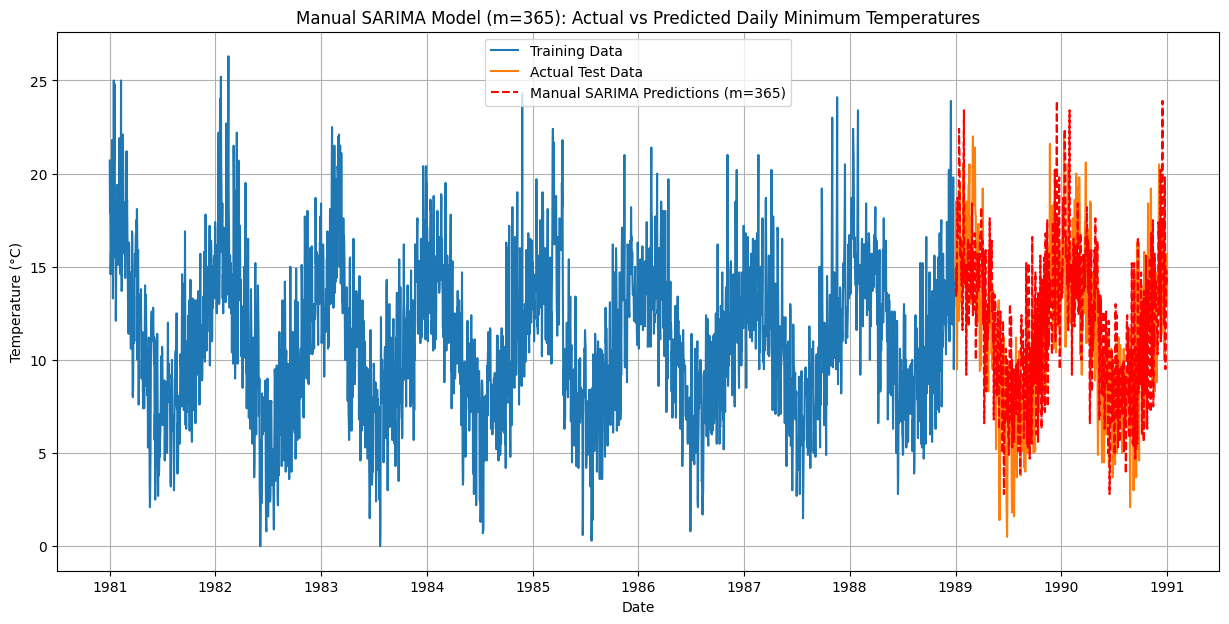

In [11]:
# Evaluate manual SARIMA model performance
manual_sarima_metrics = evaluate_model(test_data['Temperature'], manual_sarima_predictions, model_name="Manual SARIMA (m=365)")

# Visualize manual SARIMA predictions vs actuals
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['Temperature'], label='Training Data')
plt.plot(test_data.index, test_data['Temperature'], label='Actual Test Data')
plt.plot(manual_sarima_predictions.index, manual_sarima_predictions, label='Manual SARIMA Predictions (m=365)', color='red', linestyle='--')
plt.title('Manual SARIMA Model (m=365): Actual vs Predicted Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

## 8. Save the Best Model

We will save the trained `manual_sarima_fit` model using `joblib` to be able to deploy it later.

In [12]:
import joblib

# Define the filename for the saved model
model_filename = 'manual_sarima_model.joblib'

# Save the model
joblib.dump(manual_sarima_fit, model_filename)

print(f"Manual SARIMA model saved to {model_filename}")

Manual SARIMA model saved to manual_sarima_model.joblib


## 9. Deploying a Responsive Streamlit Web App

Now, let's create a Streamlit application to deploy our trained `manual_sarima_fit` model. This app will allow users to input the number of days for future temperature prediction and visualize the forecast.

In [13]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load the pre-trained SARIMA model
@st.cache_resource
def load_model():
    return joblib.load('manual_sarima_model.joblib')

model_fit = load_model()

# Load the original DataFrame (or relevant parts for display)
# For simplicity, we'll recreate df from the original CSV, assuming it's available
# In a real deployment, you might save and load the processed df as well.
@st.cache_data
def load_data():
    df = pd.read_csv('daily-minimum-temperatures-in-me.csv', on_bad_lines='skip')
    df.columns = df.columns.str.strip()
    original_temp_col_name = 'Daily minimum temperatures in Melbourne, Australia, 1981-1990'.strip()
    if original_temp_col_name in df.columns:
        df = df.rename(columns={original_temp_col_name: 'Temperature'})
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')
    df.dropna(subset=['Temperature'], inplace=True)
    return df

df_original = load_data()

# Streamlit App Title
st.title('Daily Minimum Temperature Forecasting App')

st.write("This app forecasts daily minimum temperatures using a SARIMA model.")

# Input for number of days to forecast
num_forecast_days = st.slider(
    'Select number of days to forecast into the future:',
    min_value=1,
    max_value=365,
    value=30
)

if st.button('Generate Forecast'):
    # Generate future dates for forecasting
    last_date = df_original.index.max()
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=num_forecast_days, freq='D')

    # Make predictions
    # The SARIMAX model's predict method can directly forecast future values
    forecast_start_index = len(df_original)
    forecast_end_index = len(df_original) + num_forecast_days - 1

    # Use typ='levels' for predictions in the original scale
    forecast_values = model_fit.predict(start=forecast_start_index, end=forecast_end_index, typ='levels')

    # Create a Series for the forecast with future dates as index
    forecast_series = pd.Series(forecast_values, index=future_dates)

    st.subheader(f'Forecast for the next {num_forecast_days} days:')
    st.write(forecast_series)

    # Visualize the forecast
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(df_original.index, df_original['Temperature'], label='Historical Data')
    ax.plot(forecast_series.index, forecast_series, color='red', linestyle='--', label='Forecasted Data')
    ax.set_title('Daily Minimum Temperatures: Historical and Forecast')
    ax.set_xlabel('Date')
    ax.set_ylabel('Temperature (°C)')
    ax.legend()
    ax.grid(True)
    st.pyplot(fig)

st.sidebar.header('About')
st.sidebar.info(
    "This app demonstrates time series forecasting using a SARIMA model (p=1, d=0, q=1) x (P=0, D=1, Q=0, s=365) "
    "trained on daily minimum temperatures data."
)


Writing app.py
